Cambios: 
- Implementacion noiseless simple
- Simulación via qiskit_aer (en GPUs)
- Batch parallelization via qiskit_aer pubs. Fake pubs in EstimatorQNN, Real pubs without EstimatorQNN.
- Optimicación pytorch para evaluacion en multiples GPUs
- Amplitude embedding

## Implementation (statevector simulation)

In [1]:
#--- INSTALATION INSTRUCTIONS ---#

# For linux 64-bit systems,
#uname -a

# Conda quick installation
#mkdir -p ~/miniconda3
#wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
#bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
#rm ~/miniconda3/miniconda.sh

# Create enviroment with conda
#conda create -n myenv python=3.10
#conda activate myenv
#pip install qiskit qiskit-machine-learning 'qiskit-machine-learning[sparse]' qiskit_aer qiskit_algorithms torch torchmetrics matplotlib pylatexenc ipykernelc
# IMPORTANT: Make sure you are on 3.10
# May need to restart the kernel after instalation

#--- Imports ---#
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import random_statevector, Statevector, SparsePauliOp
from qiskit.circuit.library import real_amplitudes, efficient_su2
from qiskit.utils import parallel_map
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as EstimatorV2_sim, Sampler as Sampler_sim
from qiskit_aer.quantum_info import AerStatevector
from qiskit_aer.library import SaveProbabilities

from qiskit_algorithms.gradients import ReverseEstimatorGradient

import numpy as np
import torch
import torchmetrics
import matplotlib.pyplot as plt
import time
import os
import signal
import datetime as dt

In [2]:
#- Configuration -#

# Training configuration dict
train_config = {
    'execution_type': "noiseless_simulation", #noiseless_simulation
    'n_qubits': 4,
    'seed': 1,
    'id': None, # For different circuits or training parameters
    'reset_data': True,

    'create_circuits': True, # Create circuits manually or load from file
    'gradient_method': "REG", # qiskit_algorithms.gradients For now: PSR, SPSA and REG
    'max_iterations': 1000,
    'gen_iterations': 1,
    'disc_iterations': 3,
    'batch_size': 4, # How many samples' gradients are going to be calculated in a step
    #'real_rate': 0.5, # Rate of training discriminator with real samples instead of generated samples
    'random_input': False, # Add randomness in the input when generating a sample
    'save_loss_iterations': 10, # Calculate extra forward pass to save loss
    'print_progress_iterations': 10,

    'training_data_file': None, # Automatically created with manage_files function
    'circuits_file': None, # Automatically created with manage_files function
    'backend_file': None, # Automatically created with manage_files function
    'dataset_file': None # Automatically created with manage_files function
}


# File management
def manage_files(
        data_folder_name = 'data', 
        implementation_name = 'noiseless_torch_opt_amp', 
        execution_type_name = train_config['execution_type'], 
        training_data_file_name = 'training_data', 
        circuits_file_name = 'circuits', 
        backend_file_name = 'backend',
        dataset_file_name = 'dataset'
        ):
    
    data_folder = data_folder_name + '/' + implementation_name + '/' + execution_type_name + '/' + 'q' + str(train_config['n_qubits']) + '/' + 'seed' + str(train_config['seed']) + '/'
    if train_config['id'] is not None:
        data_folder = data_folder + '/' + str(train_config['id']) + '/' 
    training_data_file = data_folder + training_data_file_name + '.pth'
    circuits_file = data_folder + circuits_file_name + '.qpy'
    backend_file = data_folder + backend_file_name + '.pkl'
    dataset_file = data_folder + dataset_file_name + '.npy'

    # Create folders if they do not exist
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)

    return training_data_file, circuits_file, backend_file, dataset_file



if ((train_config['training_data_file'] is None) and (train_config['circuits_file'] is None) and (train_config['backend_file'] is None)):
    train_config['training_data_file'], train_config['circuits_file'], train_config['backend_file'], train_config['dataset_file'] = manage_files()

In [3]:
#- Backend configuration -#
backend_config = {
    # Real backend
    'name': "ibm_basquecountry",
    'channel': "ibm_quantum_platform",

    # Noisy backend
    'reset_backend': False, # Get current backend state or load from file
    'timestamp': dt.datetime.now(), # dt.datetime(year=2026, month=12, day=5, hour = 10, tzinfo=dt.timezone.utc), # Get exact backend state, None to get current state (no he conseguido q funcione) TODO?

    # Noiseless backend
    'sim_options': {
        'method': 'statevector', # automatic, stabilizer (for clifford (simple) gates), matrix_product_state (low entanglement, more qubits), density_matrix (noise simulation, more memory (2^{2n} vs 2^n))
        #'device': 'GPU', # Para nvidia cuda
        'precision': 'single',       # Significant speedup 
        #'cuStateVec_enable': True,   # NVIDIA library optimization
        #'batched_shots_gpu': True,   # Parallelize batch on GPU [9]
        #'blocking_enable': False,     # Disable chunking; simulation fits in VRAM 
        #'target_gpus':[0,1],
        #'seed_simulator': train_config['seed']
    },

    'run_options': {
        'shots': None,
    },
}

backend = AerSimulator(**backend_config['sim_options'])

precision = 0.0
estimator = EstimatorV2_sim(
    options = {
        "default_precision": precision,
        #'seed_estimator': train_config['seed'],
        "backend_options": backend_config['sim_options'],
        "run_options": backend_config['run_options'],
    })

# sampler = Sampler_sim(**{
#     "backend_options": backend_config['sim_options'],
#     "run_options": {'shots': None},
#     "skip_transpilation": True,
#     #'seed_estimator': train_config['seed'],
# })

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
#pm = None


# Select device torch
if torch.cuda.is_available():
    print(f"GPUs available to PyTorch: {torch.cuda.device_count()}")
    os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

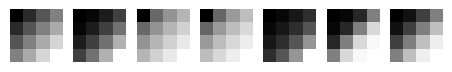

dataset shape: (7, 4, 4) 
data type: float64


In [4]:
#- Load dataset -#

# Build my own dataset of images: gradient images
def apply_curve(x, curve):
    if curve == 'linear':
        return x
    elif curve == 'quadratic':
        return x ** 2
    elif curve == 'sqrt':
        return np.sqrt(x)
    elif curve == 'log':
        return np.log1p(x * 9) / np.log(10)  # scale [0,1] into [0,1] log space
    elif curve == 'exp':
        return (np.exp(x * 3) - 1) / (np.exp(3) - 1)  # normalized exponential
    elif curve == 'sigmoid':
        return 1 / (1 + np.exp(-10 * (x - 0.5)))  # smooth S-curve
    elif curve == 'sin':
        return 0.5 * (1 - np.cos(np.pi * x))  # smooth start and end
    else:
        raise ValueError(f"Unknown curve type: {curve}")

def create_gradients(total_pixels, directions=None, curves=None, width=None, height=None):
    if directions is None:
        directions = [
            'top_left_to_bottom_right'
        ]
    if curves is None:
        curves = ['linear', 'quadratic', 'sqrt', 'log', 'exp', 'sigmoid', 'sin']

    if width is None or height is None:
        for h in range(int(np.sqrt(total_pixels)), 0, -1):
            if total_pixels % h == 0:
                width, height = total_pixels // h, h
                break
    elif width * height != total_pixels:
        raise ValueError("Provided width and height do not match total number of pixels.")

    max_val = 255
    gradients = []

    i, j = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Precompute normalized coordinate matrices for all directions
    norm_maps = {
        'left_to_right': np.tile(np.linspace(0, 1, width), (height, 1)),
        'right_to_left': np.tile(np.linspace(1, 0, width), (height, 1)),
        'top_to_bottom': np.tile(np.linspace(0, 1, height)[:, np.newaxis], (1, width)),
        'bottom_to_top': np.tile(np.linspace(1, 0, height)[:, np.newaxis], (1, width)),
        'top_left_to_bottom_right': (i + j) / (width + height - 2),
        'bottom_right_to_top_left': ((height - 1 - i) + (width - 1 - j)) / (width + height - 2),
        'top_right_to_bottom_left': (i + (width - 1 - j)) / (width + height - 2),
        'bottom_left_to_top_right': ((height - 1 - i) + j) / (width + height - 2)
    }

    for direction in directions:
        if direction not in norm_maps:
            raise ValueError(f"Unknown direction: {direction}")
        base_map = norm_maps[direction]

        for curve in curves:
            # Apply curve to normalized map
            curved_map = apply_curve(base_map, curve)
            gradients.append(curved_map)

    # Save in file
    image_array = np.array(gradients).reshape(-1, height, width)
    np.save(train_config['dataset_file'], image_array)


# Load circuits from file
try:
    X = np.load(train_config['dataset_file'])
except FileNotFoundError:
    print("Dataset file not found. Creating new dataset file.")
    create_gradients(2**train_config['n_qubits'])
    X = np.load(train_config['dataset_file'])


# Show dataset
for i in range(len(X)):
    plt.subplot(1,len(X)+1,i+1)
    plt.imshow(X[i], cmap="gray")
    plt.axis("off")
plt.show()
print("dataset shape:", X.shape, "\ndata type:", X.dtype)

In [5]:
#- Amplitude embedding -#

# Create real data sample circuit
def generate_real_circuits(matrices = None):
    n_qubits = train_config['n_qubits']

    if (matrices is None) or (matrices is []):
        ''' 
        # Random statevector
        sv = random_statevector(2**n_qubits, seed=train_config['seed'])
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(sv, qc.qubits, normalize=True) 
        '''

        # Specific statevector
        qc = QuantumCircuit(n_qubits)
        qc.h(range(n_qubits-1))
        qc.cx(n_qubits-2, n_qubits-1)
        return [qc]
    
    else:
        # Amplitude embedding
        qcs = []
        for matrix in matrices:
            qc = QuantumCircuit(n_qubits)
            qc.prepare_state(state=matrix.flatten(),
                            qubits=qc.qubits,
                            normalize=True)
            qcs.append(qc)
        return qcs

In [6]:
#- Create quantum circuits -#

# Create generator
def generate_generator():
    n_qubits = train_config['n_qubits']

    qc = real_amplitudes(n_qubits,
                        reps=3, # Number of layers
                        parameter_prefix='θ_g',
                        name='Generator').decompose()
    
    return qc


# Create random input generator
def generate_randomizer():
    n_qubits = train_config['n_qubits']

    if train_config['random_input']:
        # # Almost fully random circuit, but expensive
        # qc = efficient_su2(n_qubits,
        #                   entanglement="reverse_linear",
        #                   reps=3, # Number of layers
        #                   parameter_prefix='θ_r',
        #                   name='Randomizer').decompose()

        # Low randomness circuit, cheaper
        disc_weights = ParameterVector('θ_r', n_qubits)
        qc = QuantumCircuit(n_qubits, name="Randomizer")
        param_index = 0

        for q in range(n_qubits):
            qc.ry(disc_weights[param_index], q); param_index += 1
    else:
        qc = QuantumCircuit(n_qubits)
    
    return qc


# Create discriminator
def generate_discriminator():
    n_qubits = train_config['n_qubits']

    qc = efficient_su2(n_qubits,
                      entanglement="reverse_linear",
                      reps=1, # Number of layers
                      parameter_prefix='θ_d',
                      name='Discriminator').decompose()


    param_index = qc.num_parameters

    for i in reversed(range(n_qubits - 1)):
        qc.cx(i, n_qubits - 1)

    #qc.rx(disc_weights[param_index], N_QUBITS-1); param_index += 1
    qc.ry(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    qc.rz(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    
    return qc


# Create quantum circuits
def create_circuits(matrices = None):
    real_circuits = generate_real_circuits(matrices)
    randomizer_circuit = generate_randomizer()
    generator_circuit = generate_generator()
    discriminator_circuit = generate_discriminator()

    # Save circuits in a file
    with open(train_config['circuits_file'], 'wb') as fd:
        qpy.dump([*real_circuits, randomizer_circuit, generator_circuit, discriminator_circuit], fd)


# Rewrite circuits file if indicated in options
if train_config['create_circuits']:
    create_circuits(X)


# Load circuits from file
try:
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
except FileNotFoundError:
    print("Circuits file not found. Creating new circuits file.")
    create_circuits()
    with open(train_config['circuits_file'], 'rb') as fd:
        circuits = qpy.load(fd)
    
    
real_circuits = circuits[:(len(circuits)-3)]
randomizer_circuit = circuits[-3]
generator_circuit = circuits[-2]
discriminator_circuit = circuits[-1]

In [7]:
#- Set up training quantum circuits -#
def generate_training_circuits(real_circuits, randomizer_circuit, generator_circuit, discriminator_circuit):
    n_qubits = train_config['n_qubits']

    # Connect real data and discriminator
    real_disc_circuits = []
    for real_circuit in real_circuits:
        real_disc_circuit = QuantumCircuit(n_qubits)
        real_disc_circuit.compose(real_circuit, inplace=True)
        real_disc_circuit.compose(discriminator_circuit, inplace=True)
        real_disc_circuits.append(real_disc_circuit)

    # Connect random input and generator
    ran_gen_circuit = QuantumCircuit(n_qubits)
    ran_gen_circuit.compose(randomizer_circuit, inplace=True)
    ran_gen_circuit.compose(generator_circuit, inplace=True)

    # Connect generator and discriminator
    gen_disc_circuit = QuantumCircuit(n_qubits)
    gen_disc_circuit.compose(ran_gen_circuit, inplace=True)
    gen_disc_circuit.compose(discriminator_circuit, inplace=True)


    # Gradient computation method
    if train_config['gradient_method'] == 'SPSA':
        gradient = SPSAEstimatorGradient(estimator=estimator)
    elif train_config['gradient_method'] == 'REG':
        gradient = ReverseEstimatorGradient()
    else:
        gradient = ParamShiftEstimatorGradient(estimator=estimator)


    # Observables
    H1 = SparsePauliOp.from_list([("Z" + "I"*(n_qubits-1), 1.0)])


    N_DPARAMS = discriminator_circuit.num_parameters
    N_GPARAMS = generator_circuit.num_parameters

    trainspiled_real_disc_circuits = pm.run(real_disc_circuits)

    # specify QNN to update generator parameters
    gen_qnn = EstimatorQNN(circuit=gen_disc_circuit,
                        input_params=gen_disc_circuit.parameters[:N_DPARAMS] + gen_disc_circuit.parameters[(N_DPARAMS+N_GPARAMS):], # fixed parameters (discriminator parameters)
                        weight_params=gen_disc_circuit.parameters[N_DPARAMS:(N_DPARAMS+N_GPARAMS)], # parameters to update (generator parameters)
                        estimator=estimator,
                        observables=[H1],
                        gradient=gradient,
                        default_precision=precision,
                        pass_manager=pm
                        )

    # specify QNN to update discriminator parameters regarding to fake data
    disc_fake_qnn = EstimatorQNN(circuit=gen_disc_circuit,
                            input_params=gen_disc_circuit.parameters[N_DPARAMS:], # fixed parameters (generator parameters)
                            weight_params=gen_disc_circuit.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=[H1],
                            gradient=gradient,
                            default_precision=precision,
                            pass_manager=pm
                            )

    # specify QNN to update discriminator parameters regarding to real data
    disc_real_qnns = []
    for real_disc_circuit in trainspiled_real_disc_circuits:
        disc_real_qnn = EstimatorQNN(circuit=real_disc_circuit,
                                input_params=[], # no input parameters
                                weight_params=real_disc_circuit.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                                estimator=estimator,
                                observables=[H1],
                                gradient=gradient,
                                default_precision=precision,
                                #pass_manager=pm
                                )
        disc_real_qnns.append(disc_real_qnn)
    

    # Create generator for evaluation
    ran_gen_circuit.append(SaveProbabilities(ran_gen_circuit.num_qubits), ran_gen_circuit.qubits)
    #ran_gen_circuit.measure_all() # TODO cambiar si cambio sampler
    ran_gen_transpiled = pm.run(ran_gen_circuit)


    return gen_qnn, disc_fake_qnn, disc_real_qnns, ran_gen_transpiled, trainspiled_real_disc_circuits, gradient, H1

gen_qnn, disc_fake_qnn, disc_real_qnns, ran_gen_transpiled, trainspiled_real_disc_circuits, gradient, H1 = generate_training_circuits(real_circuits, randomizer_circuit, generator_circuit, discriminator_circuit)

In [8]:
#- Restore parameters and model states -#

# Reset all data training
def reset_data(n_gen_params, n_disc_params):
    np.random.seed(train_config['seed'])

    init_gen_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_gen_params,)) * 0.1 # Start from near 0 parameters to mitigate drastic changes at the start
    init_disc_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_disc_params,)) * 0.1

    gen_params = torch.tensor(init_gen_params, requires_grad=True, dtype = torch.float64)
    disc_params = torch.tensor(init_disc_params, requires_grad=True, dtype = torch.float64)

    optimizer_g = torch.optim.Adam([gen_params], lr=0.005)
    optimizer_d = torch.optim.Adam([disc_params], lr=0.005)

    torch.save({
        'init_gen_params': init_gen_params,
        'init_disc_params': init_disc_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'best_gen_params': init_gen_params,
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
        'current_epoch': 0,
        "metrics": {
            "gloss": {},
            "dloss": {},
            "eval": {},
            'times': {},
        },
        'random_state': np.random.get_state()
    }, train_config['training_data_file'])


# Load parameters and training states
if train_config['reset_data']:
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)

try:
    params = torch.load(train_config['training_data_file'], weights_only=False)
except FileNotFoundError:
    print("Training data file not found. Resetting parameters.")
    reset_data(generator_circuit.num_parameters, discriminator_circuit.num_parameters)
    params = torch.load(train_config['training_data_file'], weights_only=False)

np.random.set_state(params['random_state'])

gen_params = params['gen_params']
disc_params = params['disc_params']

optimizer_g = torch.optim.Adam([gen_params])
optimizer_d = torch.optim.Adam([disc_params])

optimizer_g.load_state_dict(params['optimizer_g_state'])
optimizer_d.load_state_dict(params['optimizer_d_state'])

current_epoch = params['current_epoch']
gloss = params['metrics']['gloss']
gen_loss = list(gloss)[-1] if (gloss) else None
dloss = params['metrics']['dloss']
disc_loss = list(dloss)[-1] if (dloss) else None
eval = params['metrics']['eval']
min_eval = np.min(list(eval.values())) if (eval) else float('inf')
best_gen_params = params['best_gen_params']
times = params['metrics']['times']

In [9]:
#- Manage training interruption -#

# Class to manage training interruption
class Interrupter:
    def __init__(self):
        self.kill_now = False
        self.interrupt_count = 0

        # Intercept the Ctrl+C signal
        signal.signal(signal.SIGINT, self.handle_signal)
        # Intercept the termination signal (useful for Docker/systems)
        #signal.signal(signal.SIGTERM, self.handle_signal)

    def handle_signal(self, signum, frame):
        self.interrupt_count += 1
        
        if self.interrupt_count == 1:
            # First Press: Enable graceful exit
            self.kill_now = True
            print("\nInterrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)")
        
        elif self.interrupt_count >= 2:
            # Second Press: Force quit immediately
            print("\nInterrupter: [!] Force quit triggered! Terminating immediately.")
            # Restore default signal handler to avoid recursion
            signal.signal(signal.SIGINT, signal.SIG_DFL)
            # Raise the exception to stop execution right here
            raise KeyboardInterrupt

In [10]:
#- Evualuation method -#

# Evaluation method: KL-Div of generated (ger_dists) and real (targets) samples
def evaluate(gen_dists, targets):
    gen_dists_tensor = torch.from_numpy(gen_dists).to(device)
    targets_tensor = torch.from_numpy(targets).to(device)
    return torch.nn.functional.kl_div(
        input = gen_dists_tensor.log(),
        target = targets_tensor, 
        reduction = 'batchmean' 
    ).item()


# Measure similarity by comparing luminance, contrast, and structure ([0,1], 0: identical)
img_h, img_w = X.shape[1:3]
k = max(1, min(11, min(img_h, img_w) if min(img_h, img_w) % 2 != 0 else min(img_h, img_w) - 1))
def evaluate2(gen_dists, targets):
    gen_dists_tensor = torch.from_numpy(gen_dists).to(device)
    targets_tensor = torch.from_numpy(targets).to(device)
    value = torchmetrics.functional.image.structural_similarity_index_measure(
        gen_dists_tensor.view(-1, 1, img_h, img_w), 
        targets_tensor.view(-1, 1, img_h, img_w), 
        data_range = 1.0,
        kernel_size = k,
        gaussian_kernel=False, # for images smaller than (5x5)
        reduction = "elementwise_mean",
    ).item()
    return 1 - value


# Evaluates how 'gradient-like' a batch of images is using Linear Regression ([0,1], 0: identical) (for images smaller than 4x4)
def evaluate3(gen_dists, targets = None):
    images = torch.from_numpy(gen_dists).to(device)

    b = len(images)
    h, w = img_h, img_w
    device = images.device
    
    # 2. Create the Coordinate Grid (Independent Variables X, Y and Bias)
    # This creates a matrix of [H*W, 3] where rows are [x_coord, y_coord, 1]
    y_coords, x_coords = torch.meshgrid(torch.arange(h, device=device), 
                                        torch.arange(w, device=device), 
                                        indexing='ij')
    
    # Flatten coordinates and add a column of ones for the 'c' (intercept)
    X = torch.stack([x_coords.flatten(), y_coords.flatten(), 
                     torch.ones(h * w, device=device)], dim=1).float()
    
    # Prepare target values (Dependent Variable Z / Intensity)
    y = images.view(b, h * w, 1).float()
    
    # Solve for Coefficients [a, b, c]
    X_batch = X.unsqueeze(0).expand(b, -1, -1)
    solution = torch.linalg.lstsq(X_batch, y).solution
    
    # Calculate Predictions and R^2 Score
    y_pred = X_batch @ solution
    
    # Residual Sum of Squares (Error)
    ss_res = torch.sum((y - y_pred) ** 2, dim=1)
    
    # Total Sum of Squares (Variance from mean)
    y_mean = torch.mean(y, dim=1, keepdim=True)
    ss_tot = torch.sum((y - y_mean) ** 2, dim=1)
    
    # R^2 calculation (adding epsilon to avoid division by zero on flat colors)
    r2 = (ss_res / (ss_tot + 1e-10)) # 1 - ... (cambiado para min best)
    
    return torch.clamp(r2, 0, 1).mean().item()


# Evaluate specific gradient (numpy) ([0,1], 0: identical)
def evaluate4(gen_dists, targets = None):
    batch = gen_dists.reshape(-1, img_h, img_w)
    
    h_penalty = np.mean(np.abs(np.minimum(0, np.diff(batch, axis=2))))
    v_penalty = np.mean(np.abs(np.minimum(0, np.diff(batch, axis=1))))
    
    return (h_penalty + v_penalty) / 2

In [11]:
#- Batch parallelization -#

# Create random input
def generate_random_input(batch_size, num_params):
    return np.random.uniform(0, 2 * np.pi, size=(batch_size, num_params)) #* 0.1 # TODO Randomness


# Compute batch gradients method
batch_method = 3
if batch_method == 1:
    # Compute forward and bacward pass in parallel
    def compute_single_forward_disc(data_index, disc_params_np):
        cost = disc_real_qnns[data_index].forward([], disc_params_np)[0,0]
        return cost

    def compute_single_gradient_disc(data_index, disc_params_np):
        grad = disc_real_qnns[data_index].backward([], disc_params_np)[1][0,0]
        return grad

    # Compute forward an backward pass of a batch (parallel_map)
    def compute_batch_forward_disc(data_indexes, disc_params_np):
        costs = parallel_map(compute_single_forward_disc, data_indexes, task_args=[disc_params_np], num_processes=1)
        return np.array(costs)

    def compute_batch_gradient_disc(data_indexes, disc_params_np):
        grads = parallel_map(compute_single_gradient_disc, data_indexes, task_args=[disc_params_np], num_processes=1) # TODO cambia num_processes para bender
        return np.array(grads)
    
elif batch_method == 2:
    # Compute forward an backward pass of a batch (loop, aer manages to parallelize)
    def compute_batch_forward_disc(data_indexes, disc_params_np):
        costs = np.array()
        for data_index in data_indexes:
            cost = disc_real_qnns[data_index].forward([], disc_params_np)[0,0]
            costs.append(cost)
        return costs

    def compute_batch_gradient_disc(data_indexes, disc_params_np):
        grads = np.array()
        for data_index in data_indexes:
            grad = disc_real_qnns[data_index].backward([], disc_params_np)[1][0,0]
            grads.append(grad)
        return grads

elif batch_method == 3:
    # Compute forward an backward pass of a batch (with pubs, no EstimatorQNN)
    def compute_batch_forward_disc(data_indexes, disc_params_np):
        pubs = [(trainspiled_real_disc_circuits[i], [H1], [disc_params_np]) for i in data_indexes]
        results = estimator.run(pubs).result()
        costs = np.array([res.data.evs for res in results]).flatten()
        return costs

    def compute_batch_gradient_disc(data_indexes, disc_params_np):
        circuits = [trainspiled_real_disc_circuits[i] for i in data_indexes]
        result = gradient.run(circuits, [H1]*len(data_indexes), [disc_params_np]*len(data_indexes), parameters=[discriminator_circuit.parameters]*len(data_indexes)).result()
        grads = grads = np.array(result.gradients)
        return grads


# Evaluate batch of generated samples with real samples (batch Sampler)
def batch_evaluation(real_data, batch_size, n_rparams, gen_params_np):
    # Get inputs to generate fake samples
    inputs = np.concatenate((np.tile(gen_params_np, (batch_size, 1)), generate_random_input(batch_size, n_rparams)), axis=1)
    parameter_binds = {ran_gen_transpiled.parameters[i]: [float(values[i]) for values in inputs] for i in range(len(ran_gen_transpiled.parameters))}
    
    # Get fake samples
    job = backend.run([ran_gen_transpiled], parameter_binds=[parameter_binds], **backend_config['run_options'])
    result = job.result()
    all_counts = [result.data(i)['probabilities'] for i in range(len(result.results))]
    gen_dists_np = np.array(all_counts)

    # # Get real samples
    real_data_indexes = [np.random.randint(0, len(real_data)) for i in range(batch_size)]  
    targets = real_data[real_data_indexes]

    # Evaluate fake sample similarity to real samples
    current_kl = evaluate4(gen_dists_np)
    #current_kl = evaluate(gen_dists_np, targets)
    return current_kl

In [ ]:
#- Training -#

# Params
D_STEPS = train_config['disc_iterations']
G_STEPS = train_config['gen_iterations']
C_STEPS = train_config['save_loss_iterations']

batch_size = train_config['batch_size']
fake_batch_size = max(batch_size // 2, 1) # This is for when batch_size is odd
real_batch_size = batch_size - (batch_size // 2) # This is for when batch_size is odd
N_RPARAMS = randomizer_circuit.num_parameters

# Compute real distributions
real_distribution_tensors = []
for real_circuit in real_circuits:
    real_distribution_tensor = torch.from_numpy(AerStatevector(real_circuit).probabilities()) # Retrieve real data probability distribution 
    real_distribution_tensors.append(real_distribution_tensor)
real_data = torch.stack(real_distribution_tensors).to(device)

interrupter = Interrupter()

if train_config['print_progress_iterations']:
    TABLE_HEADERS = "Epoch | Generator cost | Discriminator cost | Evaluation | Best eval | Time |"
    print(TABLE_HEADERS)

prev_times = 0
start_time = time.time()

#--- Training loop ---#
try: # In case of interruption
    for epoch in range(current_epoch, train_config['max_iterations']+1):

        #--- Quantum discriminator parameter updates ---#
        for disc_train_step in range(D_STEPS):
            gen_params_np = gen_params.detach().cpu().numpy()
            disc_params_np = disc_params.detach().cpu().numpy()

            inputs = np.concatenate((np.tile(gen_params_np, (fake_batch_size, 1)), generate_random_input(fake_batch_size, N_RPARAMS)), axis=1)
            data_indexes = [np.random.randint(0, len(disc_real_qnns)) for i in range(real_batch_size)]  

            # Calculate discriminator cost (optional)
            if (disc_train_step == D_STEPS - 1) and (epoch % C_STEPS == 0):
                # Calculate real sample costs
                real_costs = compute_batch_forward_disc(data_indexes, disc_params_np)
                
                # Calculate fake sample costs
                fake_costs = -disc_fake_qnn.forward(inputs, disc_params_np)[:,0]

                all_costs = np.concatenate((real_costs, fake_costs), axis=0)
                disc_loss = np.sum(all_costs, axis=0) / (len(all_costs) * 2) - 0.5 # to [-1,0]
                dloss[epoch] = disc_loss

            # Caltulate discriminator real sample gradient
            real_grads = compute_batch_gradient_disc(data_indexes, disc_params_np)

            # Calculate discriminator fake sample gradient
            fake_grads = -disc_fake_qnn.backward(inputs, disc_params_np)[1][:,0]

            all_grads = np.concatenate((real_grads, fake_grads), axis=0)
            grad_dcost_adjoint = np.mean(all_grads, axis=0)
            
            # Update discriminator parameters
            optimizer_d.zero_grad()
            disc_params.grad = torch.tensor(grad_dcost_adjoint, dtype = torch.float64, device=device)
            optimizer_d.step()


        #--- Quantum generator parameter updates ---#
        for gen_train_step in range(G_STEPS):
            gen_params_np = gen_params.detach().cpu().numpy()
            disc_params_np = disc_params.detach().cpu().numpy()

            inputs = np.concatenate((np.tile(disc_params_np, (batch_size, 1)), generate_random_input(batch_size, N_RPARAMS)), axis=1)

            # Calculate generator cost
            if (gen_train_step == G_STEPS - 1) and (epoch % C_STEPS == 0):
                all_costs = gen_qnn.forward(inputs, gen_params_np)[:,0]
                gen_loss = np.sum(all_costs, axis=0) / (len(all_costs) * 2) - 0.5 # to [-1,0]
                gloss[epoch] = gen_loss

            # Calculate generator gradient
            all_grads = gen_qnn.backward(inputs, gen_params_np)[1][:,0]
            grad_gcost_adjoint = np.mean(all_grads, axis=0)

            # Update generator parameters
            optimizer_g.zero_grad()
            gen_params.grad = torch.tensor(grad_gcost_adjoint, dtype = torch.float64, device=device)
            optimizer_g.step()


        # Performance measurement function 
        current_kl = batch_evaluation(real_data, batch_size*2, N_RPARAMS, gen_params_np) # TODO Crear TorchConnector con ran+gen para solo evaluar? + cambiar batch_evaluation para funcionar con torch
        
        eval[epoch] = current_kl
        if min_eval > current_kl:
            min_eval = current_kl
            best_gen_params = gen_params_np.copy() # New best


        # Calculate time
        cur_time = (time.time() - start_time)
        times[epoch] = cur_time
        start_time = time.time()


        #--- Print progress ---#
        if train_config['print_progress_iterations'] and (epoch % train_config['print_progress_iterations'] == 0):
            now_times = sum(times.values())
            for header, val in zip(TABLE_HEADERS.split('|'),
                                (epoch, gen_loss, disc_loss, current_kl, min_eval, now_times - prev_times)):
                print(f"{val:.3g} ".rjust(len(header)), end="|")
            print()

            prev_times = now_times

        # In case of interruption
        if interrupter.kill_now:
            print("Interrupter: Graceful exit triggered. Breaking loop.")
            break

#--- Save parameters and optimizer states data ---#
finally:
    torch.save({
        'init_gen_params': params['init_gen_params'],
        'init_disc_params': params['init_disc_params'],
        'best_gen_params': best_gen_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
        'current_epoch': epoch+1,
        "metrics": {
            "gloss": gloss,
            "dloss": dloss,
            "eval": eval,
            'times': times,
        },
        'random_state': np.random.get_state()
    }, train_config['training_data_file'])
    
    eval_data = list(eval.values()) if eval else [0]
    print("Training complete:", "\n   Data path:", train_config['training_data_file'], "\n   Best eval:", min(eval_data), "in epoch", np.argmin(eval_data), "\n   Improvement:", eval_data[0]-min(eval_data), "\n   Total time:", sum(times.values()))

Epoch | Generator cost | Discriminator cost | Evaluation | Best eval | Time |
    0 |         -0.187 |              -0.81 |     0.0775 |    0.0775 | 2.74 |
   10 |         -0.149 |              -0.86 |     0.0756 |    0.0756 | 8.04 |
   20 |         -0.177 |             -0.895 |     0.0731 |    0.0731 | 7.66 |
   30 |         -0.191 |             -0.835 |     0.0693 |    0.0693 | 7.74 |

Interrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)
Interrupter: Graceful exit triggered. Breaking loop.
Training complete: 
   Data path: data/noiseless_torch_opt_amp/noiseless_simulation/q4/seed1/training_data.pth 
   Best eval: 0.06541749684114014 in epoch 38 
   Improvement: 0.01203449345916853 
   Total time: 32.132370710372925
